# Plot R ggtree circular phylogenetic trees 

- This notebook generates circular phylogenetic trees with R ggtree (aesthetically look better than the python ete3 default plot)
- Reproduce the HCT116 homopolymer 10-14bp vs 15-50bp circular phylogenetic trees from the paper

## Requirements:
- Newick tree file
- CSV samplesheet with columns: sample_id, color, group


## 1. Setup and Package Installation


In [ ]:
# Install required packages if not already installed
# Uncomment the lines below if you need to install packages

# if (!requireNamespace("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")
# 
# install.packages(c("ape", "dplyr", "ggplot2"))
# BiocManager::install(c("ggtree", "ggtreeExtra"))


In [ ]:
# Load required libraries
suppressPackageStartupMessages({
  library(ggtree)
  library(ggtreeExtra)
  library(ape)
  library(dplyr)
  library(ggplot2)
})


## 2. Configuration Parameters

Adjust these parameters to customize your visualization:


## 1nt12k 10-14bp Dataset Visualization

In [ ]:
# Configuration parameters - MODIFY THESE AS NEEDED

# File paths - choose your dataset
SAMPLESHEET_FILE <- "/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/20230117_HCT116_1nt12k10to14bp_samplesheet.csv"
TREE_FILE <- "/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/results_1nt12k10-14bp_500targets_minqual0/phylo/20230117_HCT116_1nt12k10-14bp.buildPhylo.newick-original.txt"
OUTPUT_PREFIX <- "20230117_HCT116_1nt12k10to14bp_circular_ggtree"

# Visual parameters
COLOR_BACKGROUND <- FALSE  # Set to TRUE to apply colors to text background instead of node circles
PLOT_WIDTH <- 16
PLOT_HEIGHT <- 12
DPI <- 500
TIP_LABEL_SIZE <- 3.7
NODE_SIZE <- 3
LEGEND_TEXT_SIZE <- 22
LEGEND_TITLE_SIZE <- 24

# Ring parameters
INNER_RING_OFFSET <- 1.6
RING_WIDTH <- 4

cat("Configuration set:\n")
cat("Samplesheet:", SAMPLESHEET_FILE, "\n")
cat("Tree file:", TREE_FILE, "\n")
cat("Output prefix:", OUTPUT_PREFIX, "\n")
cat("Color background:", COLOR_BACKGROUND, "\n")


Configuration set:
Samplesheet: /home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/20230117_HCT116_1nt12k10to14bp_samplesheet.csv 
Tree file: /home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/results_1nt12k10-14bp_500targets_minqual0/phylo/20230117_HCT116_1nt12k10-14bp.buildPhylo.newick-original.txt 
Output prefix: 20230117_HCT116_1nt12k10to14bp_circular_ggtree 
Color background: FALSE 


## 3. Data Loading and Preprocessing


In [ ]:
# Load tree
tree <- read.tree(TREE_FILE)

cat("Tree loaded successfully!\n")
cat("Number of tips:", length(tree$tip.label), "\n")
cat("Tree type:", class(tree), "\n")

# Display first few tip labels
cat("\nFirst 10 tip labels:\n")
print(head(tree$tip.label, 10))


Tree loaded successfully!
Number of tips: 41 
Tree type: phylo 

First 10 tip labels:
 [1] "2-1-C4_3-7-G7_Plate2-1C" "2-1-C4_3-7-G7_Plate2-3D"
 [3] "2-1-C4_3-7-G7_Plate2-1D" "2-1-C4_3-7-G7_Plate2-1E"
 [5] "2-1-C4_3-7-G7_Plate2-1F" "2-1-C4_3-7-G7_Plate2-2B"
 [7] "2-1-C4_3-7-G7_Plate2-2C" "2-1-C4_3-7-G7_Plate2-2F"
 [9] "2-1-C4_3-7-G7_Plate2-3E" "2-1-C4_3-7-G7_Plate2-2D"


In [ ]:
# Load sample data
samples <- read.csv(SAMPLESHEET_FILE, stringsAsFactors = FALSE)

cat("Sample data loaded successfully!\n")
cat("Number of samples:", nrow(samples), "\n")
cat("Columns:", colnames(samples), "\n")

# Display first few rows
cat("\nFirst few rows of sample data:\n")
print(head(samples))

# Check for unique groups
cat("\nUnique groups:\n")
print(unique(samples$group))


Sample data loaded successfully!
Number of samples: 54 
Columns: sample_id ms_fastq_1 meth_fastq_1 group color 

First few rows of sample data:
                sample_id
1 2-1-C4_3-7-G7_Plate2-1B
2 2-1-C4_3-7-G7_Plate2-1C
3 2-1-C4_3-7-G7_Plate2-1D
4 2-1-C4_3-7-G7_Plate2-1E
5 2-1-C4_3-7-G7_Plate2-1F
6 2-1-C4_3-7-G7_Plate2-1G
                                                                                                                                                                                ms_fastq_1
1 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/0_Raw_Data/Fastq/MS_1nt12k10-14bp_HCT116_SC_2-1-C4_3-7-G7_20230110_Plate2-1B.fastq.gz
2 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/0_Raw_Data/Fastq/MS_1nt12k10-14bp_HCT116_SC_2-1-C4_3-7-G7_20230110_Plate2-1C.fastq.gz
3 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/0_Raw_Data/F

In [ ]:
# Handle missing values with defaults
if (!'color' %in% colnames(samples)) {
  samples$color <- 'grey'
  cat("Added default 'color' column\n")
} else {
  samples$color <- ifelse(is.na(samples$color) | samples$color == '', 'grey', samples$color)
  cat("Processed 'color' column\n")
}

# Display updated sample data
cat("\nSample data structure:\n")
print(str(samples))


Processed 'color' column

Sample data structure:
'data.frame':	54 obs. of  5 variables:
 $ sample_id   : chr  "2-1-C4_3-7-G7_Plate2-1B" "2-1-C4_3-7-G7_Plate2-1C" "2-1-C4_3-7-G7_Plate2-1D" "2-1-C4_3-7-G7_Plate2-1E" ...
 $ ms_fastq_1  : chr  "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/0_Raw_Data/F"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/0_Raw_Data/F"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/0_Raw_Data/F"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp/0_Raw_Data/F"| __truncated__ ...
 $ meth_fastq_1: logi  NA NA NA NA NA NA ...
 $ group       : chr  "2-1-C4_3-7-G7" "2-1-C4_3-7-G7" "2-1-C4_3-7-G7" "2-1-C4_3-7-G7" ...
 $ color       : chr  "#f4a6a6" "#f4a6a6" "#f4a6a6" "#f4a6a6" ...
NULL


## 4. Data Preparation for Visualization


In [ ]:
# Prepare data for tree - only color column for tip labels
tip_label_data <- samples %>% 
  select(sample_id, color) %>%
  rename(label = sample_id)
rownames(tip_label_data) <- tip_label_data$label

# Prepare data for inner ring with group names for legend
group_ring_data <- samples %>%
  select(sample_id, color, group) %>%
  rename(label = sample_id)

cat("Data preparation completed!\n")
cat("Tip label data rows:", nrow(tip_label_data), "\n")
cat("Group ring data rows:", nrow(group_ring_data), "\n")


Data preparation completed!
Tip label data rows: 54 
Group ring data rows: 54 


In [ ]:
# Custom rename dictionary for group names (customize as needed)
rename_dict <- list(
  'Brain_LeftAnteriorCortex' = 'Brain Left Anterior Cortex',
  'Brain_LeftPosteriorCortex' = 'Brain Left Posterior Cortex',
  'Kidney_Left-Cortex-1' = 'Kidney Left Cortex',
  'Kidney_Right-Cortex-1' = 'Kidney Right Cortex',
  'Liver_LeftLobe' = 'Liver Left Lobe',
  'Liver_MedianLobe' = 'Liver Median Lobe',
  'Liver_RightLobe' = 'Liver Right Lobe'
)

# Function to rename based on dictionary, leave unchanged if not in dict
rename_labels <- function(x, dict) {
  sapply(x, function(name) {
    if (name %in% names(dict)) {
      dict[[name]]
    } else {
      name
    }
  })
}

# Apply custom renaming to group names
group_names_clean <- rename_labels(unique(samples$group), rename_dict)
group_colors_map <- setNames(unique(samples$color), group_names_clean)

# Update the group_ring_data to use cleaned names
group_ring_data$group <- rename_labels(group_ring_data$group, rename_dict)

cat("Label cleaning completed!\n")
cat("Group colors map:\n")
print(group_colors_map)


Label cleaning completed!
Group colors map:
2-1-C4_3-7-G7 2-1-F7_3-3-B9 2-1-H9_3-4-D8 
    "#f4a6a6"     "#b8d4b8"     "#a8c8ec" 


## 5. Tree Visualization


In [ ]:
# Set plot size for notebook display
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 150)

# Basic tree plot - circular layout only
p <- ggtree(tree, layout = 'circular', branch.length = 'none', size = 1)

# Join ONLY color data to tree for tip labels
p <- p %<+% tip_label_data

cat("Basic tree structure created!\n")


Basic tree structure created!


In [ ]:
# Add tip labels with or without background color
if (COLOR_BACKGROUND) {
  # Text with colored background - smaller font to avoid overlap
  p <- p + geom_tiplab(aes(fill = color), 
                       size = TIP_LABEL_SIZE, color = 'black', 
                       geom = 'label', 
                       label.padding = unit(0.1, "lines")) +
    scale_fill_identity()
  cat("Added colored background tip labels\n")
} else {
  # Colored node circles with plain text - smaller font with offset
  p <- p + geom_tippoint(aes(color = color), size = NODE_SIZE) +
    geom_tiplab(size = TIP_LABEL_SIZE, offset = 0.6) +  # Small offset to push text away from nodes
    scale_color_identity()
  cat("Added colored node circles with plain text labels\n")
}


Added colored node circles with plain text labels


In [ ]:
# Add inner continuous ring for group color with legend
p <- p + geom_fruit(
    data = group_ring_data,
    geom = geom_tile,
    mapping = aes(y = label, x = 2, fill = group),
    pwidth = 0.1,
    width = RING_WIDTH,
    offset = INNER_RING_OFFSET
  ) + 
  scale_fill_manual(
    values = group_colors_map,
    name = "HCT116 Clone",  # <-- CHANGE THIS to your desired title
    # guide = guide_legend(
    #   keyheight = unit(2, "lines"),  # <-- ADD THIS for more row spacing
    #   keywidth = unit(1.5, "lines"),   # <-- ADD THIS for wider keys
    #   label.position = "right",        # <-- ADD THIS for text position
    #   byrow = TRUE                     # <-- ADD THIS for row arrangement
    # )
    # To turn OFF legend completely, replace the guide_legend(...) above with:
    guide = "none"
  )

cat("Added inner ring for group colors\n")


! The following column names/name: color are/is the same to tree data, the tree data column names are : label, y, angle, color.



Added inner ring for group colors


Applied final theming


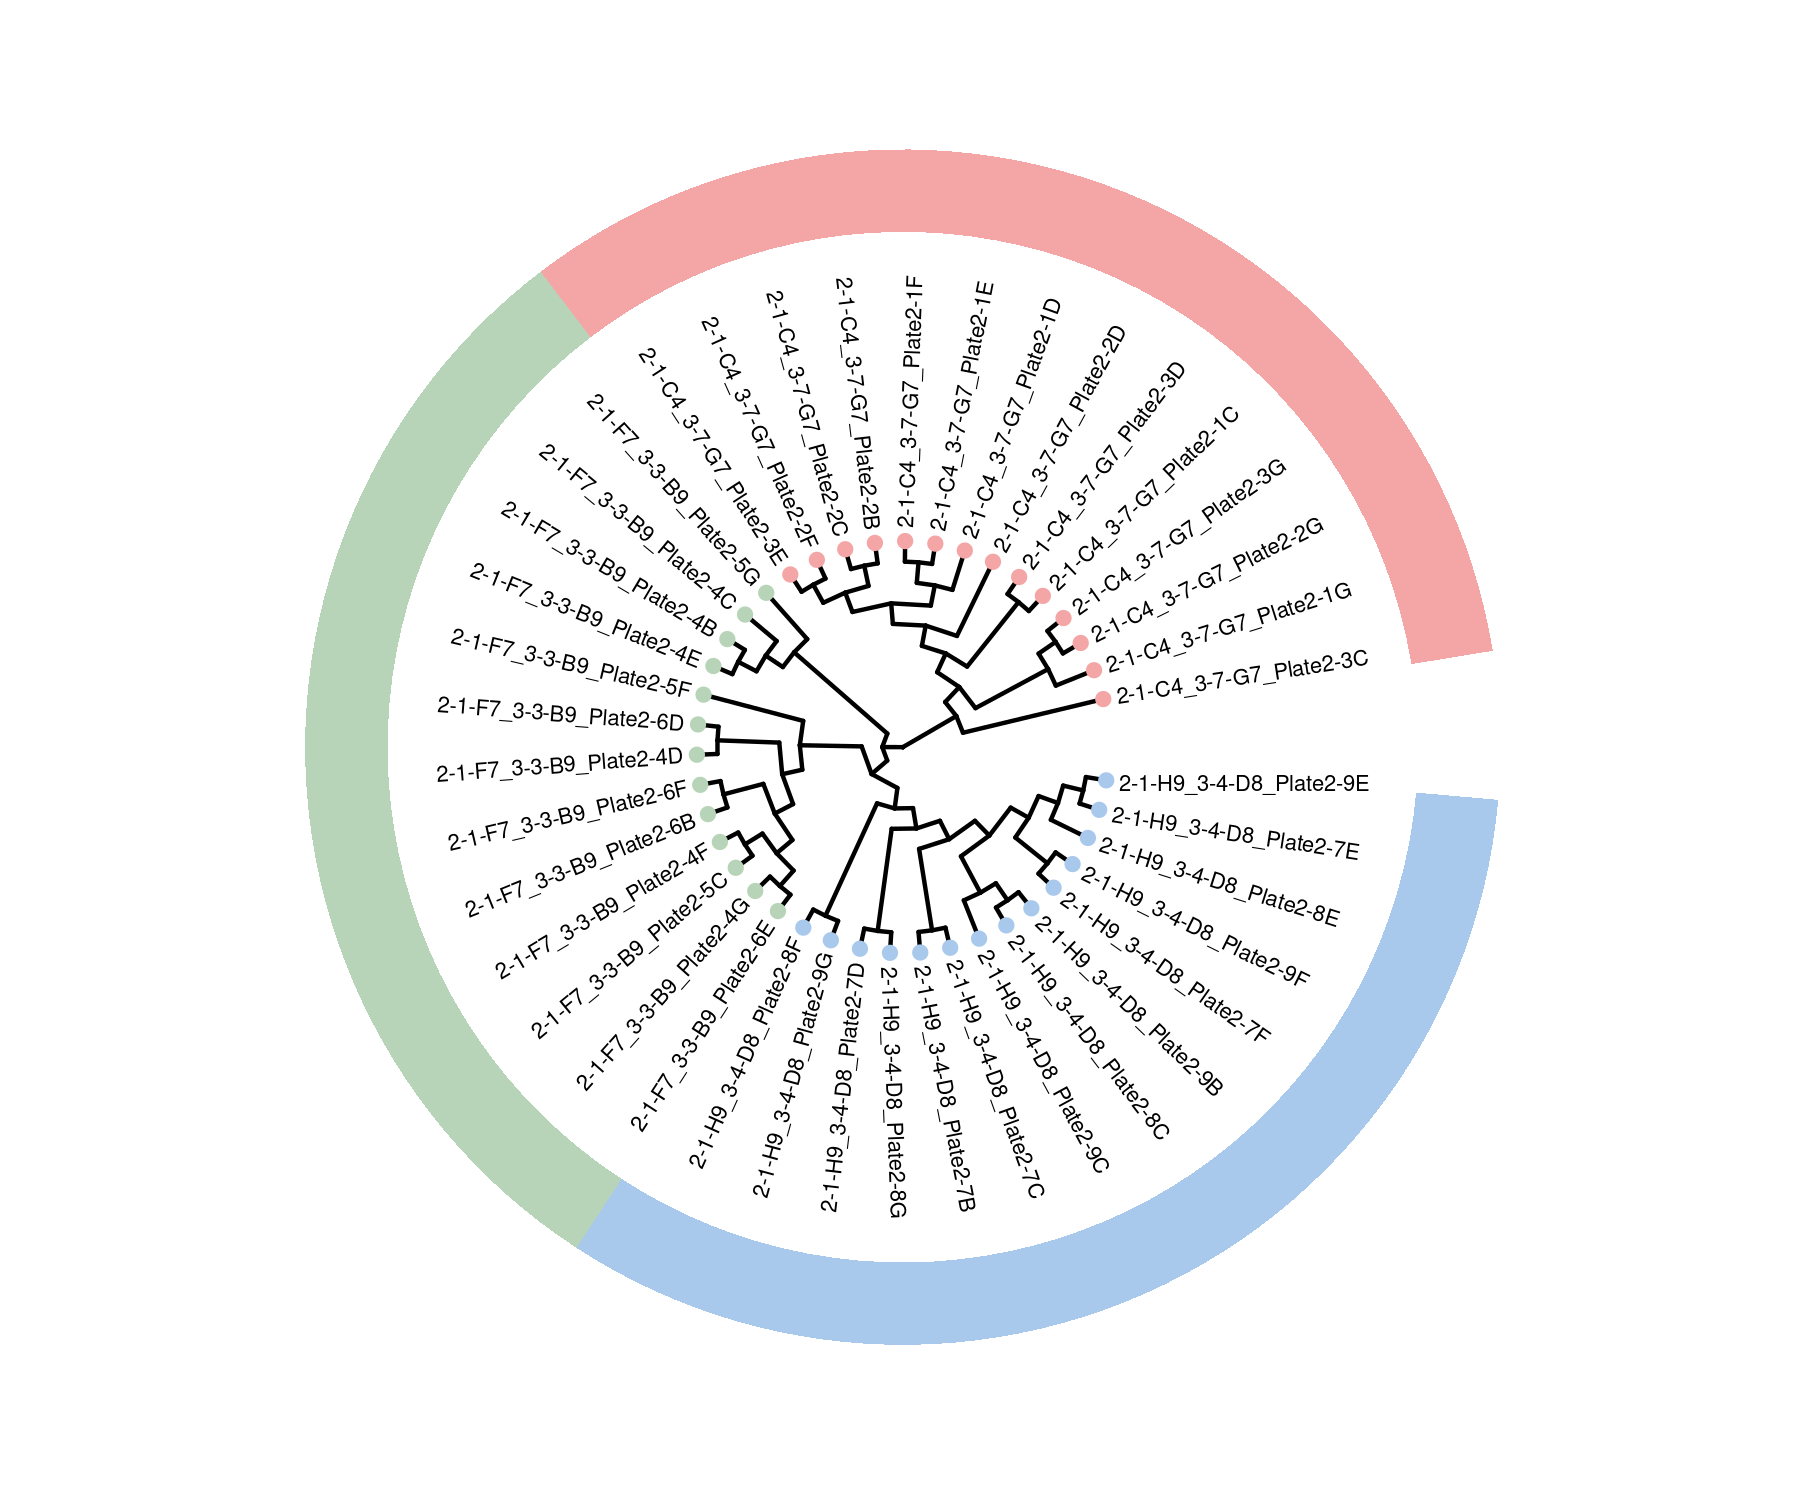

In [ ]:
# Adjust plot margins and theme, and position legends
p <- p + theme(
  plot.margin = margin(0, 0, 0, 0),  # Remove all margins
  legend.text = element_text(size = LEGEND_TEXT_SIZE),  # Larger legend text
  legend.title = element_text(size = LEGEND_TITLE_SIZE, face = "bold"),  # Larger, bold legend titles
  legend.background = element_rect(fill = "white", colour = NA)  # White background, no border
) +
  theme(
    legend.position.inside = c(0.85, 0.5),  # Apply position separately
    legend.justification = c(0.5, 0.5)  # Center anchor
  )

cat("Applied final theming\n")

# Display the plot
print(p)


In [ ]:
# Save outputs
ggsave(paste0(OUTPUT_PREFIX, '.viewPhylo.pdf'), p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)
ggsave(paste0(OUTPUT_PREFIX, '.viewPhylo.png'), p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)

cat("Tree visualization saved to:\n")
cat(paste0("  ", OUTPUT_PREFIX, ".viewPhylo.pdf\n"))
cat(paste0("  ", OUTPUT_PREFIX, ".viewPhylo.png\n"))


Tree visualization saved to:
  20230117_HCT116_1nt12k10to14bp_circular_ggtree.viewPhylo.pdf
  20230117_HCT116_1nt12k10to14bp_circular_ggtree.viewPhylo.png


## 1nt12k 15-50bp Dataset Visualization

Now let's create the same visualization using the 1nt12k 15-50bp dataset:


In [ ]:
# Configuration for 1nt12k 15-50bp dataset
BP1550_SAMPLESHEET_FILE <- "/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/20230117_HCT116_1nt12k15to50bp_samplesheet.csv"
BP1550_TREE_FILE <- "results_1nt12k15-50bp_500targets_minqual0/phylo/20230117_HCT116_1nt12k15-50bp.buildPhylo.newick-original.txt"
BP1550_OUTPUT_PREFIX <- "20230117_HCT116_1nt12k15to50bp_circular_ggtree"

cat("1nt12k 15-50bp Configuration:\n")
cat("Samplesheet:", BP1550_SAMPLESHEET_FILE, "\n")
cat("Tree file:", BP1550_TREE_FILE, "\n")
cat("Output prefix:", BP1550_OUTPUT_PREFIX, "\n")


1nt12k 15-50bp Configuration:
Samplesheet: /home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/20230117_HCT116_1nt12k15to50bp_samplesheet.csv 
Tree file: results_1nt12k15-50bp_500targets_minqual0/phylo/20230117_HCT116_1nt12k15-50bp.buildPhylo.newick-original.txt 
Output prefix: 20230117_HCT116_1nt12k15to50bp_circular_ggtree 


In [ ]:
# Load 1nt12k 15-50bp tree and sample data
bp1550_tree <- read.tree(BP1550_TREE_FILE)
bp1550_samples <- read.csv(BP1550_SAMPLESHEET_FILE, stringsAsFactors = FALSE)

# Handle missing values with defaults
bp1550_samples$color <- ifelse(is.na(bp1550_samples$color) | bp1550_samples$color == '', 'grey', bp1550_samples$color)

cat("1nt12k 15-50bp data loaded:\n")
cat("Tree tips:", length(bp1550_tree$tip.label), "\n")
cat("Samples:", nrow(bp1550_samples), "\n")
cat("Unique groups:", length(unique(bp1550_samples$group)), "\n")
print(unique(bp1550_samples$group))


1nt12k 15-50bp data loaded:
Tree tips: 52 
Samples: 54 
Unique groups: 3 
[1] "2-1-C4_3-7-G7" "2-1-F7_3-3-B9" "2-1-H9_3-4-D8"


In [ ]:
# Prepare 1nt12k 15-50bp data for visualization
bp1550_tip_label_data <- bp1550_samples %>% 
  select(sample_id, color) %>%
  rename(label = sample_id)
rownames(bp1550_tip_label_data) <- bp1550_tip_label_data$label

bp1550_group_ring_data <- bp1550_samples %>%
  select(sample_id, color, group) %>%
  rename(label = sample_id)

# Apply label cleaning
bp1550_group_ring_data$group <- rename_labels(bp1550_group_ring_data$group, rename_dict)
bp1550_group_names_clean <- rename_labels(unique(bp1550_samples$group), rename_dict)
bp1550_group_colors_map <- setNames(unique(bp1550_samples$color), bp1550_group_names_clean)

cat("1nt12k 15-50bp data preparation completed!\n")
cat("Group colors map:\n")
print(bp1550_group_colors_map)


1nt12k 15-50bp data preparation completed!
Group colors map:
2-1-C4_3-7-G7 2-1-F7_3-3-B9 2-1-H9_3-4-D8 
    "#f4a6a6"     "#b8d4b8"     "#a8c8ec" 


In [ ]:
# Create 1nt12k 15-50bp circular tree visualization
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 150)

# Basic tree plot
bp1550_p <- ggtree(bp1550_tree, layout = 'circular', branch.length = 'none', size = 1)

# Join color data to tree for tip labels
bp1550_p <- bp1550_p %<+% bp1550_tip_label_data

# Add tip labels (using same style as 1nt12k 10-14bp)
if (COLOR_BACKGROUND) {
  bp1550_p <- bp1550_p + geom_tiplab(aes(fill = color), 
                             size = TIP_LABEL_SIZE, color = 'black', 
                             geom = 'label', 
                             label.padding = unit(0.1, "lines")) +
    scale_fill_identity()
} else {
  bp1550_p <- bp1550_p + geom_tippoint(aes(color = color), size = NODE_SIZE) +
    geom_tiplab(size = TIP_LABEL_SIZE, offset = 0.5) +
    scale_color_identity()
}

cat("1nt12k 15-50bp basic tree structure created!\n")


1nt12k 15-50bp basic tree structure created!


! The following column names/name: color are/is the same to tree data, the tree data column names are : label, y, angle, color.



1nt12k 15-50bp visualization completed!


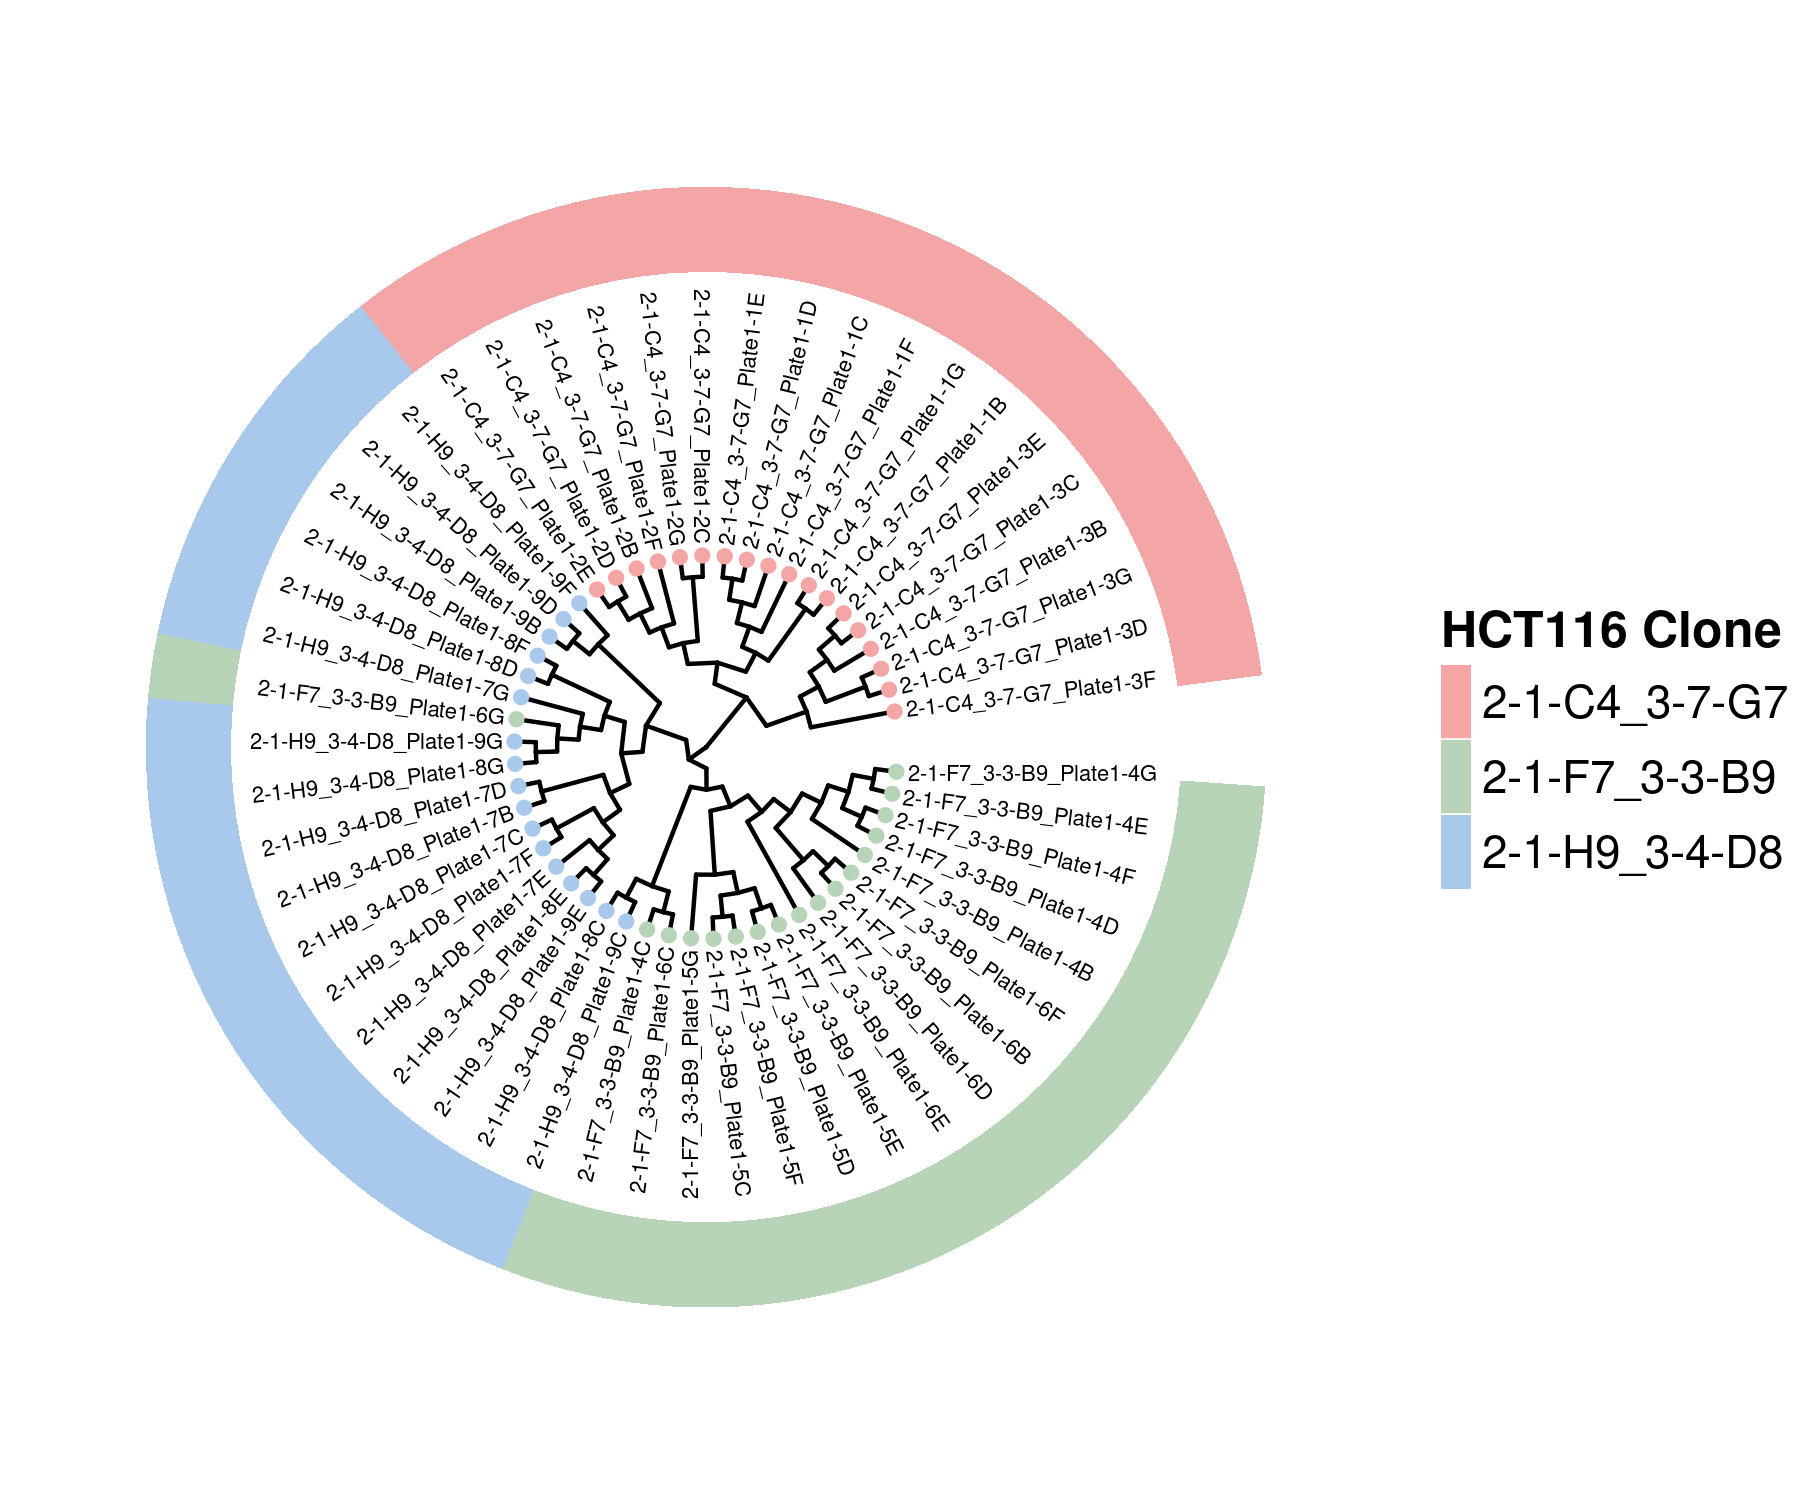

In [ ]:
# Add inner ring and styling for 1nt12k 15-50bp
bp1550_p <- bp1550_p + geom_fruit(
    data = bp1550_group_ring_data,
    geom = geom_tile,
    mapping = aes(y = label, x = 2, fill = group),
    pwidth = 0.1,
    width = RING_WIDTH,
    offset = INNER_RING_OFFSET
  ) + 
  scale_fill_manual(
    values = bp1550_group_colors_map,
    name = "HCT116 Clone",
    guide = guide_legend(
      keyheight = unit(2.5, "lines"),
      keywidth = unit(1, "lines"),
      label.position = "right",
      byrow = TRUE
    )
    # To turn OFF legend completely, replace the guide_legend(...) above with:
    # guide = "none"
  )

# Apply theming
bp1550_p <- bp1550_p + theme(
  plot.margin = margin(0, 0, 0, 0),
  legend.text = element_text(size = LEGEND_TEXT_SIZE),
  legend.title = element_text(size = LEGEND_TITLE_SIZE, face = "bold"),
  legend.background = element_rect(fill = "white", colour = NA)
) +
  theme(
    legend.position.inside = c(0.85, 0.5),
    legend.justification = c(0.5, 0.5)
  )

cat("1nt12k 15-50bp visualization completed!\n")

# Display the plot
print(bp1550_p)


In [ ]:
# Save 1nt12k 15-50bp outputs
ggsave(paste0(BP1550_OUTPUT_PREFIX, '.viewPhylo.pdf'), bp1550_p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)
ggsave(paste0(BP1550_OUTPUT_PREFIX, '.viewPhylo.png'), bp1550_p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)

cat("1nt12k 15-50bp tree visualization saved to:\n")
cat(paste0("  ", BP1550_OUTPUT_PREFIX, ".viewPhylo.pdf\n"))
cat(paste0("  ", BP1550_OUTPUT_PREFIX, ".viewPhylo.png\n"))


1nt12k 15-50bp tree visualization saved to:
  20230117_HCT116_1nt12k15to50bp_circular_ggtree.viewPhylo.pdf
  20230117_HCT116_1nt12k15to50bp_circular_ggtree.viewPhylo.png


## Summary

This notebook now creates visualizations for both datasets:

1. **1nt12k 10-14bp** (Sections 1-9): Creates `20230117_HCT116_1nt12k10to14bp_circular_ggtree.viewPhylo.pdf/png`
2. **1nt12k 15-50bp** (Section 10): Creates `20230117_HCT116_1nt12k15to50bp_circular_ggtree.viewPhylo.pdf/png`

### Legend Options:
- **Show legend**: Use `guide = guide_legend(...)` (current setting)
- **Hide legend**: Replace with `guide = "none"`

### Quick Tips:
- Both visualizations use the same styling parameters from Section 2
- The 1nt12k 15-50bp section reuses all the same functions and styling
- You can modify legend spacing, colors, and titles in both sections independently
